<a href="https://colab.research.google.com/github/HelenDiMo/P.A.W.L-e---Robot-Paseador-de-Perros/blob/main/pAwL_E2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import random
import time
registro_perros = {} # Aquí guardaremos { "Nombre": Numero_de_paseos }

# ==========================================
# PARTE 1: DEFINICIÓN (La Clase)
# ==========================================
class RobotPaseador:
    def __init__(self, nombre_robot):
        self.nombre = "P.A.W.L-e"  # El nombre del aparato (P.A.W.L-E)
        self.bateria = 100
        self.bolsas = 10
        self.felicidad_perro = 0
        self.perro_actual = ""

    def saludar(self):
        print(f"✨ [SISTEMA]: {self.nombre} se ha encendido. ¡Listo para pasear a {self.perro_actual}!")

    def autodiagnostico(self):
        """El robot informa cómo se siente (Lógica de juego)"""
        print(f"\n--- 📊 Reporte de {self.nombre} ---")
        print(f"Energía: {self.bateria}% | Bolsas: {self.bolsas} | Felicidad: {self.felicidad_perro}")
        # Lógica de decisión simple
        if self.bateria < 30:
            print(f"⚠️ {self.nombre} dice: '¡Batería baja! Debemos volver pronto.'")
        if self.bolsas == 0:
            print(f"⚠️ {self.nombre} dice: '¡Sin bolsas! No podemos permitir que el perro ensucie.'")

    def pasear(self):
        """Simula un tramo del paseo"""
        print(f"\n👣 {self.perro_actual} está caminando...")
        # Gastamos recursos
        self.bateria -= 12
        self.felicidad_perro += 10
        if random.random() < 0.5:
            print("💩 ¡El perro ha hecho sus necesidades!")
            self.bolsas -= 1

    def autorecarga(self, cantidad=10):
        """Gestiona la entrada de energía (Solar)"""
        self.bateria = min(100, self.bateria + cantidad)
        print(f"☀️ ¡SOL! {self.nombre} ha recargado +{cantidad}%.")

    def escanear_ruta(self):
        """Lógica de detección de obstáculos"""
        obstaculos = ["un charco enorme", "barro seco", "cristales", "asfalto caliente"]
        peligro = random.choice(obstaculos)
        print(f"📡 [RADAR]: ¡Cuidado! Detectado {peligro}.")
        print(f"🔄 {self.nombre} recalculando ruta para proteger a {self.perro_actual}...")
        self.bateria -= 2  # Coste de maniobra


# ==========================================
# PARTE 2: MENÚ DE INICIO
# ==========================================

print("=== 🦴 BIENVENIDO AL CENTRO DE CONTROL P.A.W.L-E ===")
print()

pawle = RobotPaseador("P.A.W.L-E v2.0")

nombre_perro_input = input("Introduce el nombre de tu perro: ").strip().capitalize()
pawle.perro_actual = nombre_perro_input

print()

# --- LÓGICA DE MEMORIA ---
# 2. LÓGICA DE ACTUALIZACIÓN AUTOMÁTICA
if pawle.perro_actual in registro_perros:
    # Si ya existe, le sumamos 1 paseo
    registro_perros[pawle.perro_actual] += 1
    print(f"❤️ ¡RECONOCIMIENTO! Hola de nuevo, {pawle.perro_actual}.")
    print(f"Este es vuestro paseo número {registro_perros[pawle.perro_actual]} juntos.")
else:
    # Si es nuevo, lo anotamos con el valor 1
    registro_perros[pawle.perro_actual] = 1
    print(f"🆕 ¡ENCANTADO DE CONOCERTE! He creado un perfil para {pawle.perro_actual}.")

minutos_input = input("¿Cuánto tiempo durará el paseo? (ej: 30, 45, 60): ")
print()


pawle.saludar()
print()

# Convertimos a número y creamos el objeto
meta_tiempo = int(minutos_input)
historial_bateria = [100]
historial_tiempo = [0]
tiempo_transcurrido = 0
regresando = False

print(f"🚀 Iniciando recolección de datos para {pawle.nombre}...")

pawle.autodiagnostico()

while tiempo_transcurrido < meta_tiempo and pawle.bateria > 0:
  tiempo_transcurrido += 5 # Cada paso dura 5 minutos
  print(f"\n--- 🕐 Minuto {tiempo_transcurrido} ---")

  # LÓGICA DE RETORNO UNIFICADA

  if (pawle.bolsas <= 1 or pawle.bateria <= 40) and not regresando:
    print(f"🚨 {pawle.nombre} ACTIVANDO PROTOCOLO DE RETORNO:")
    if pawle.bateria <= 40: print("- Motivo: Energía crítica.")
    if pawle.bolsas <= 1: print("- Motivo: Escasez de bolsas.")
    regresando = True

  if regresando:
    gasto_energia = 4 # Gasta poquito porque va directo a casa
    print(f"🚶 {pawle.nombre} camina despacio hacia casa para ahorrar...")
    pawle.bateria -= 4 # Gasta menos porque no juega

  elif random.random() < 0.2: # 20% de probabilidad
    gasto_energia = 0
    print("☀️ ¡ENERGÍA SOLAR! P.A.W.L-E recarga mientras camina. Gasto: 0%")
    recarga_energia = 10
    pawle.bateria = min(100, pawle.bateria + recarga_energia)
    print(f"☀️ ¡SOL! {pawle.nombre} ha recargado +{recarga_energia}%.")

  elif random.random() < 0.3: # Evento Radar
    pawle.escanear_ruta() # Usamos el método de la clase

  else:
    gasto_energia = 12 # Gasta mucho porque está jugando
    pawle.pasear() # Aquí corre, juega y gasta 12 (como antes)


    if pawle.bateria < 0: pawle.bateria = 0
    if pawle.bateria > 100: pawle.bateria = 100

    # 2. GUARDAR DATOS (Al final de cada vuelta)
    historial_bateria.append(pawle.bateria)
    historial_tiempo.append(tiempo_transcurrido)

  pawle.autodiagnostico()
  time.sleep(random.uniform(0.5, 1.5)) # Si usamos: time.sleep(n) - Cuanto mayor sea (n), mas tiempo de espera // si usamos time.sleep(random.uniform(0.5, 1.5)) - Va a parecer que el robot está pensando.

# --- RESULTADO FINAL ---
if pawle.bateria > 0:
    print(f"\n✅ {pawle.nombre} ha llegado a casa sano y salvo.")
else:
    print(f"\n💀 {pawle.nombre} se quedó sin energía. Necesitas ir a rescatarlo.")
# --- MÉTRICA FINAL ---
print("\n" + "="*30)
print("📊 DATOS RECOLECTADOS (Historial de Batería):")
print(historial_bateria)
print("\n⏰ MINUTOS TRANSCURRIDOS:")
print(historial_tiempo)
print("="*30)

# Ajustes de seguridad y guardado de datos
pawle.bateria = max(0, min(100, pawle.bateria))
historial_bateria.append(pawle.bateria)
historial_tiempo.append(tiempo_transcurrido)


=== 🦴 BIENVENIDO AL CENTRO DE CONTROL P.A.W.L-E ===

Introduce el nombre de tu perro: Bob

🆕 ¡ENCANTADO DE CONOCERTE! He creado un perfil para Bob.
¿Cuánto tiempo durará el paseo? (ej: 30, 45, 60): 30

✨ [SISTEMA]: P.A.W.L-e se ha encendido. ¡Listo para pasear a Bob!

🚀 Iniciando recolección de datos para P.A.W.L-e...

--- 📊 Reporte de P.A.W.L-e ---
Energía: 100% | Bolsas: 10 | Felicidad: 0

--- 🕐 Minuto 5 ---
📡 [RADAR]: ¡Cuidado! Detectado un charco enorme.
🔄 P.A.W.L-e recalculando ruta para proteger a Bob...

--- 📊 Reporte de P.A.W.L-e ---
Energía: 98% | Bolsas: 10 | Felicidad: 0

--- 🕐 Minuto 10 ---

👣 Bob está caminando...

--- 📊 Reporte de P.A.W.L-e ---
Energía: 86% | Bolsas: 10 | Felicidad: 10

--- 🕐 Minuto 15 ---

👣 Bob está caminando...

--- 📊 Reporte de P.A.W.L-e ---
Energía: 74% | Bolsas: 10 | Felicidad: 20

--- 🕐 Minuto 20 ---

👣 Bob está caminando...
💩 ¡El perro ha hecho sus necesidades!

--- 📊 Reporte de P.A.W.L-e ---
Energía: 62% | Bolsas: 9 | Felicidad: 30

--- 🕐 Minuto 

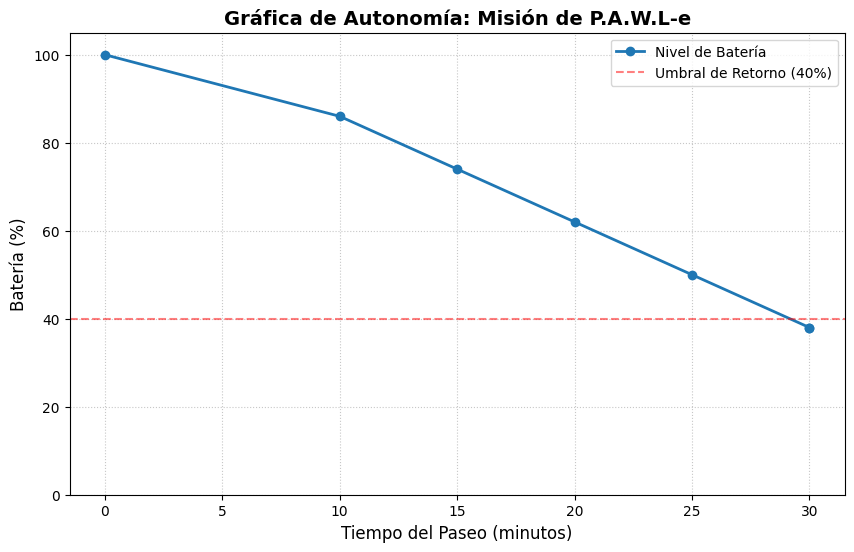

In [15]:
import matplotlib.pyplot as plt

# 1. Configurar el lienzo
plt.figure(figsize=(10, 6))

# 2. Dibujar la línea de energía
plt.plot(historial_tiempo, historial_bateria,
         color='#1f77b4', marker='o', linestyle='-', linewidth=2, label='Nivel de Batería')

# 3. Dibujar la "Zona de Peligro" (Umbral de 40%)
plt.axhline(y=40, color='red', linestyle='--', alpha=0.5, label='Umbral de Retorno (40%)')

# 4. Personalizar con títulos y rejilla
plt.title(f"Gráfica de Autonomía: Misión de {pawle.nombre}", fontsize=14, fontweight='bold')
plt.xlabel("Tiempo del Paseo (minutos)", fontsize=12)
plt.ylabel("Batería (%)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.ylim(0, 105) # Para que se vea el 100% arriba y el 0% abajo
plt.legend()

# 5. ¡Mostrar al mundo!
plt.show()